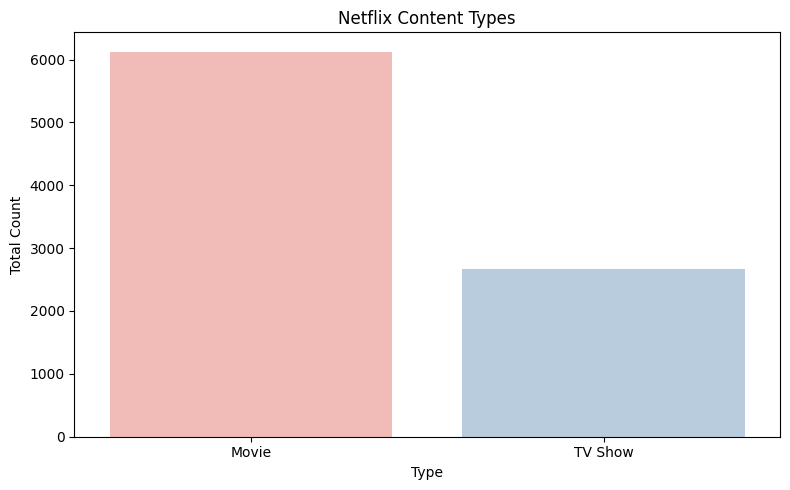

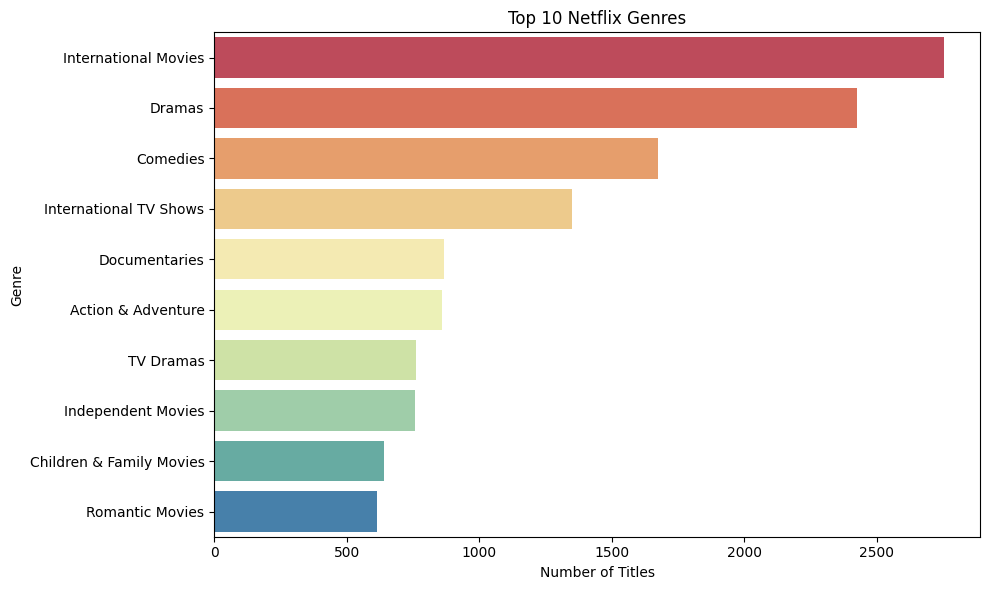

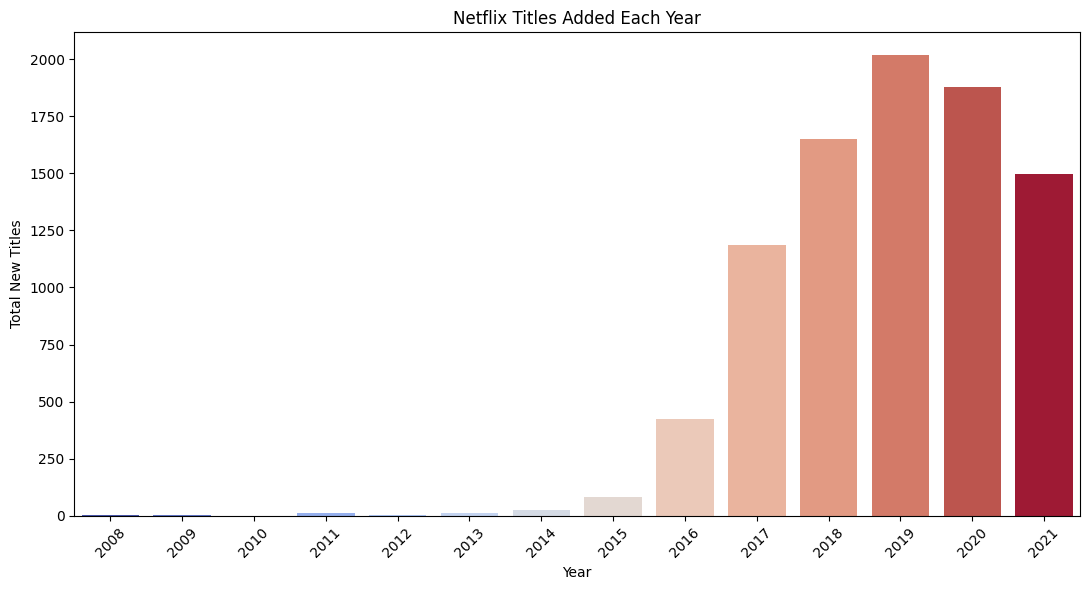

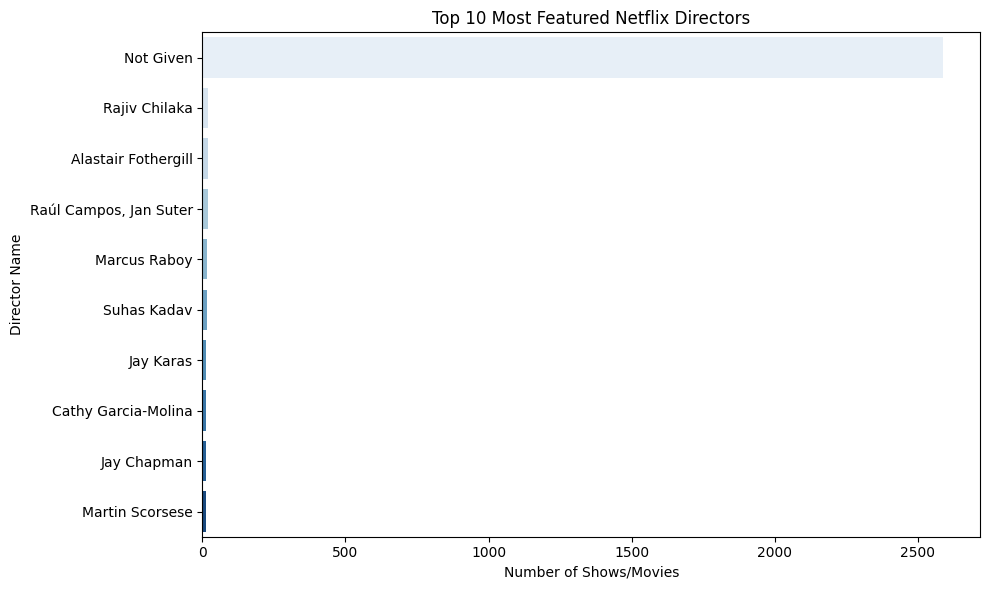

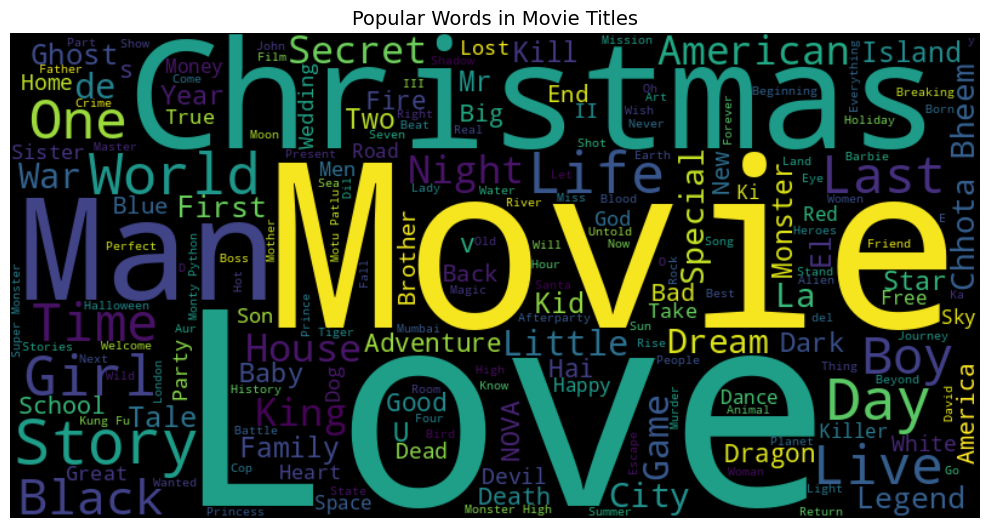

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load dataset
df = pd.read_csv('/content/netflix1.csv')

# Initial cleaning
df.drop_duplicates(inplace=True)
df.dropna(subset=['director', 'listed_in', 'country'], inplace=True)
df['date_added'] = pd.to_datetime(df['date_added'])

# ---------------------- Content Type Distribution ----------------------
content_summary = df['type'].value_counts().reset_index()
content_summary.columns = ['Content_Type', 'Total']

plt.figure(figsize=(8, 5))
sns.barplot(data=content_summary, x='Content_Type', y='Total', palette='Pastel1', hue='Content_Type', dodge=False, legend=False)
plt.title('Netflix Content Types')
plt.xlabel('Type')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

# ---------------------- Top Genres ----------------------
df['genre_list'] = df['listed_in'].str.split(',')
all_genres = [genre.strip() for sublist in df['genre_list'] for genre in sublist]
top_genres = pd.Series(all_genres).value_counts().nlargest(10).reset_index()
top_genres.columns = ['Genre', 'Frequency']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_genres, y='Genre', x='Frequency', palette='Spectral', hue='Genre', dodge=False, legend=False)
plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

# ---------------------- Yearly Additions ----------------------
df['year'] = df['date_added'].dt.year
df['month'] = df['date_added'].dt.month

annual_adds = df['year'].value_counts().sort_index().reset_index()
annual_adds.columns = ['Year', 'Count']

plt.figure(figsize=(11, 6))
sns.barplot(data=annual_adds, x='Year', y='Count', palette='coolwarm', hue='Year', dodge=False, legend=False)
plt.title('Netflix Titles Added Each Year')
plt.xlabel('Year')
plt.ylabel('Total New Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------- Most Featured Directors ----------------------
top_directors = df['director'].value_counts().nlargest(10).reset_index()
top_directors.columns = ['Director', 'Appearances']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_directors, y='Director', x='Appearances', palette='Blues', hue='Director', dodge=False, legend=False)
plt.title('Top 10 Most Featured Netflix Directors')
plt.xlabel('Number of Shows/Movies')
plt.ylabel('Director Name')
plt.tight_layout()
plt.show()

# ---------------------- Word Cloud of Movie Titles ----------------------
movie_names = df[df['type'] == 'Movie']['title']
word_cloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(movie_names))

plt.figure(figsize=(10, 6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Popular Words in Movie Titles', fontsize=14)
plt.tight_layout()
plt.show()
